In [19]:
import sys
from pathlib import Path
import importlib

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.config
import src.data.load_data
import src.features.preprocess

importlib.reload(src.config)
importlib.reload(src.data.load_data)
importlib.reload(src.features.preprocess)

from src.config import DATA_PATH, PROJECT_ROOT
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_PATH =", DATA_PATH)
print("DATA_PATH exists? =", Path(DATA_PATH).exists())

PROJECT_ROOT = /Users/galaxygab/Desktop/Recurrent-Neural-Networks-for-Disease-Progression-Prediction
DATA_PATH = /Users/galaxygab/Desktop/Recurrent-Neural-Networks-for-Disease-Progression-Prediction/data/raw/Pima_Diabetes.csv
DATA_PATH exists? = True


In [20]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_raw_data, basic_data_summary
from src.features.preprocess import (
    ZERO_AS_MISSING_COLUMNS,
    count_zero_values,
    preprocess_pima_data,
)

print("Project root:", project_root)

raw_df = load_raw_data()
summary = basic_data_summary(raw_df)

summary

Project root: /Users/galaxygab/Desktop/Recurrent-Neural-Networks-for-Disease-Progression-Prediction


{'shape': (768, 9),
 'columns': ['Class',
  'Times Pregnant',
  'Blood Glucose',
  'Blood Pressure',
  'Skin Fold Thickness',
  '2-Hour Insulin',
  'BMI',
  'Family History',
  'Age'],
 'target_column': 'Class',
 'class_distribution': {0: 500, 1: 268},
 'missing_values': {'Class': 0,
  'Times Pregnant': 0,
  'Blood Glucose': 0,
  'Blood Pressure': 0,
  'Skin Fold Thickness': 0,
  '2-Hour Insulin': 0,
  'BMI': 0,
  'Family History': 0,
  'Age': 0},
 'dtypes': {'Class': 'int64',
  'Times Pregnant': 'int64',
  'Blood Glucose': 'int64',
  'Blood Pressure': 'int64',
  'Skin Fold Thickness': 'int64',
  '2-Hour Insulin': 'int64',
  'BMI': 'float64',
  'Family History': 'float64',
  'Age': 'int64'}}

In [21]:
print("Shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

print("\nFirst 5 rows:")
display(raw_df.head())

print("\nClass distribution:")
print(raw_df["Class"].value_counts())

print("\nMissing values:")
print(raw_df.isna().sum())

print("\nDescriptive statistics:")
display(raw_df.describe())

Shape: (768, 9)

Columns:
['Class', 'Times Pregnant', 'Blood Glucose', 'Blood Pressure', 'Skin Fold Thickness', '2-Hour Insulin', 'BMI', 'Family History', 'Age']

First 5 rows:


,Class,Times Pregnant,Blood Glucose,Blood Pressure,Skin Fold Thickness,2-Hour Insulin,BMI,Family History,Age
0,1,6,148,72,35,0,33.6,0.627,50
1,0,1,85,66,29,0,26.6,0.351,31
2,1,8,183,64,0,0,23.3,0.672,32
3,0,1,89,66,23,94,28.1,0.167,21
4,1,0,137,40,35,168,43.1,2.288,33



Class distribution:
Class
0    500
1    268
Name: count, dtype: int64

Missing values:
Class                  0
Times Pregnant         0
Blood Glucose          0
Blood Pressure         0
Skin Fold Thickness    0
2-Hour Insulin         0
BMI                    0
Family History         0
Age                    0
dtype: int64

Descriptive statistics:


,Class,Times Pregnant,Blood Glucose,Blood Pressure,Skin Fold Thickness,2-Hour Insulin,BMI,Family History,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.348958,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,0.476951,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,0.000000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,0.000000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,1.000000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,1.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [22]:
zero_counts = count_zero_values(raw_df, ZERO_AS_MISSING_COLUMNS)
zero_counts

{'Blood Glucose': 5,
 'Blood Pressure': 35,
 'Skin Fold Thickness': 227,
 '2-Hour Insulin': 374,
 'BMI': 11}

### Note on Data Cleaning
In the Pima dataset, several features contain zero values that are medically implausible in real patients, including glucose, blood pressure, skin fold thickness, insulin, and BMI. These are treated as missing values and imputed using the median so the pipeline remains clinically reasonable and robust.

In [23]:
clean_df, zero_counts_before, missing_after_zero_replacement = preprocess_pima_data()

print("Zero counts before cleaning:")
print(zero_counts_before)

print("\nMissing values immediately after zero replacement:")
print(missing_after_zero_replacement)

print("\nMissing values after imputation:")
print(clean_df.isna().sum())

display(clean_df.head())

Zero counts before cleaning:
{'Blood Glucose': 5, 'Blood Pressure': 35, 'Skin Fold Thickness': 227, '2-Hour Insulin': 374, 'BMI': 11}

Missing values immediately after zero replacement:
{'Class': 0, 'Times Pregnant': 0, 'Blood Glucose': 5, 'Blood Pressure': 35, 'Skin Fold Thickness': 227, '2-Hour Insulin': 374, 'BMI': 11, 'Family History': 0, 'Age': 0}

Missing values after imputation:
Class                  0
Times Pregnant         0
Blood Glucose          0
Blood Pressure         0
Skin Fold Thickness    0
2-Hour Insulin         0
BMI                    0
Family History         0
Age                    0
dtype: int64


,Class,Times Pregnant,Blood Glucose,Blood Pressure,Skin Fold Thickness,2-Hour Insulin,BMI,Family History,Age
0,1,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0
1,0,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0
2,1,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0
3,0,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,1,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


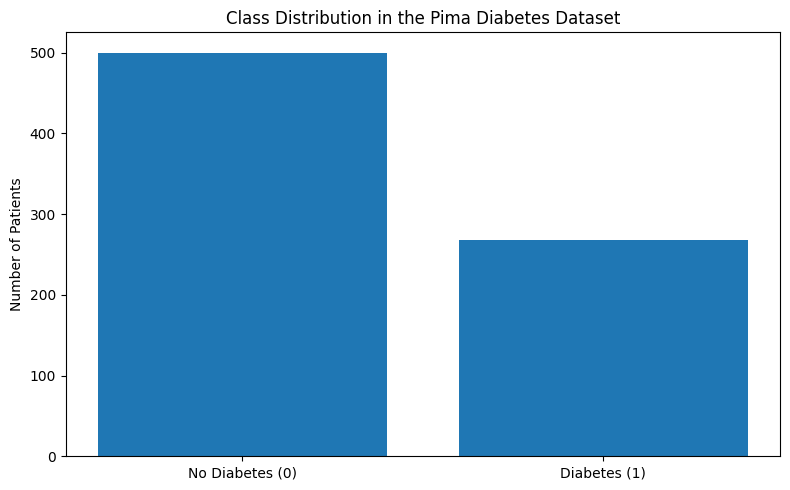

In [24]:
fig_path = project_root / "outputs" / "figures"
fig_path.mkdir(parents=True, exist_ok=True)

class_counts = raw_df["Class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(["No Diabetes (0)", "Diabetes (1)"], class_counts.values)
plt.title("Class Distribution in the Pima Diabetes Dataset")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig(fig_path / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

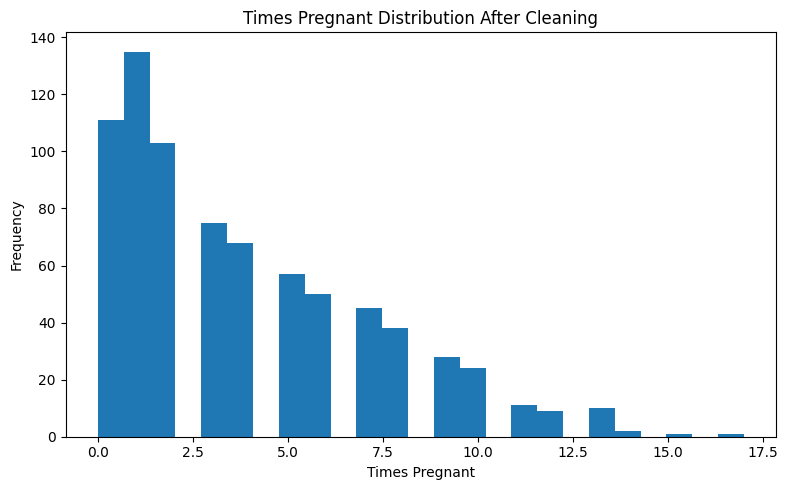

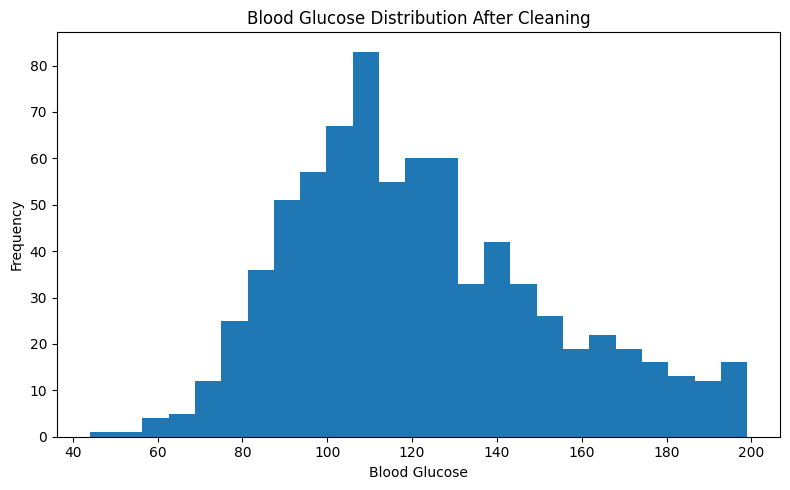

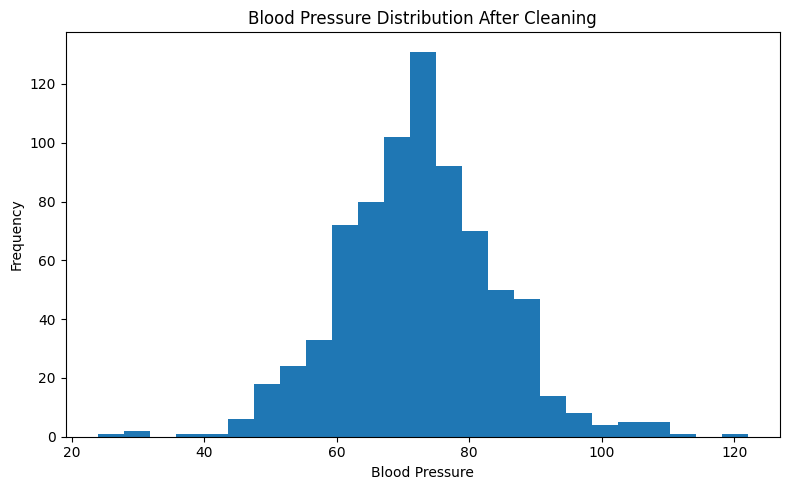

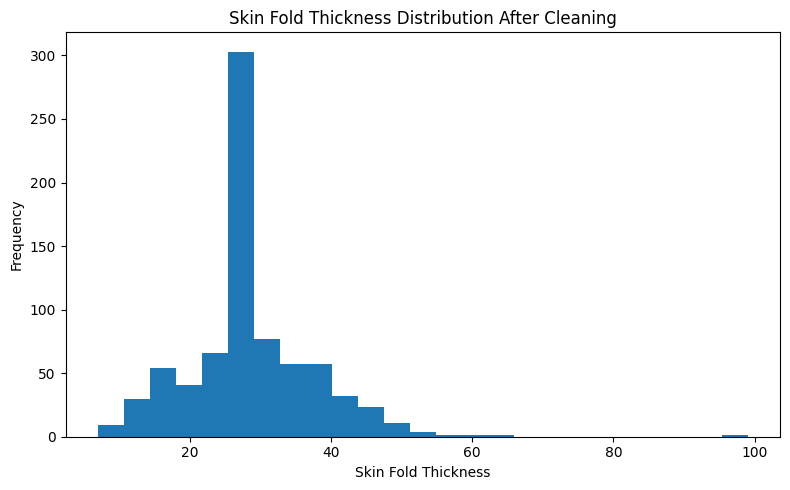

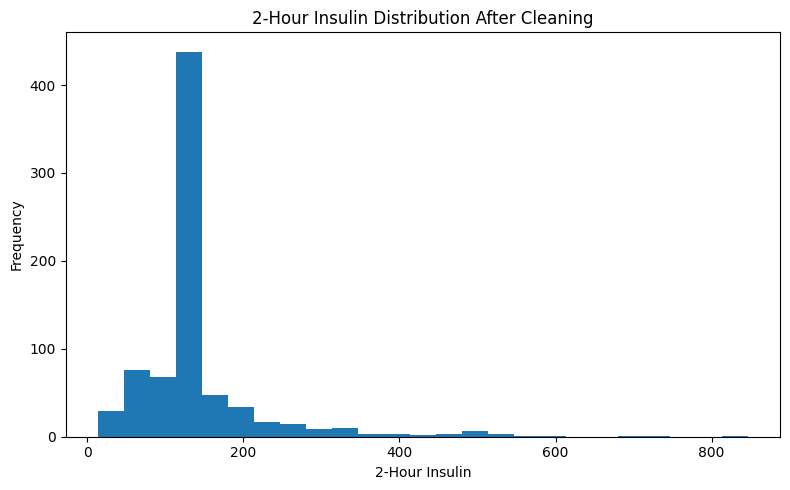

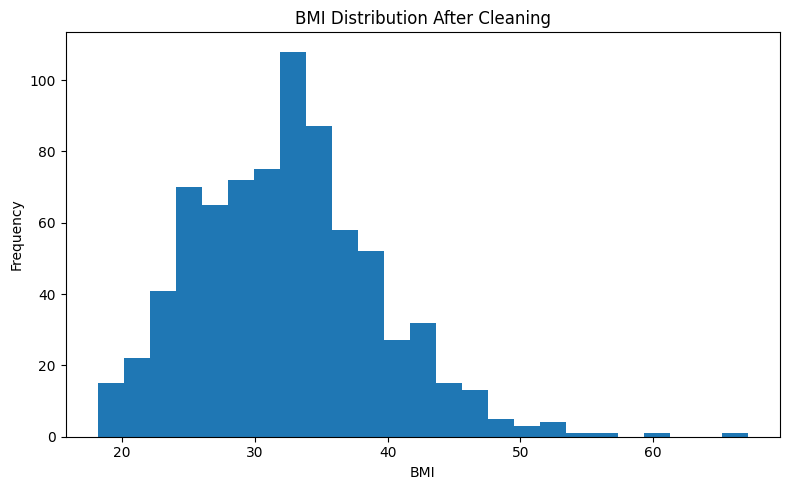

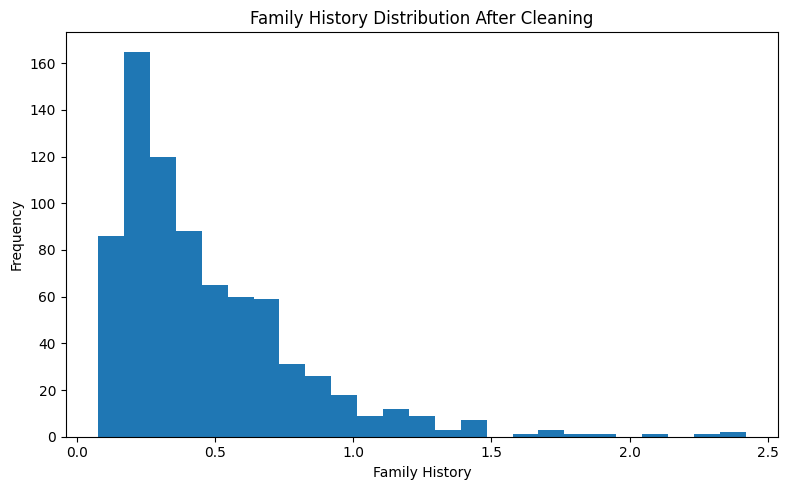

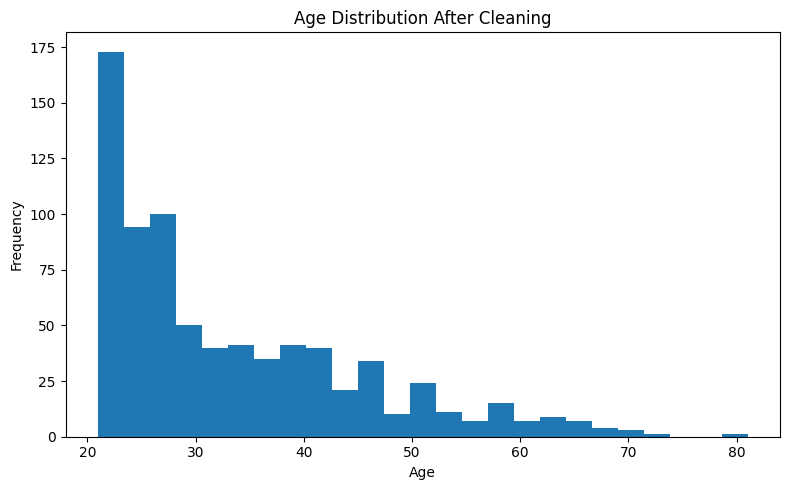

In [25]:
feature_columns = [col for col in clean_df.columns if col != "Class"]

for feature in feature_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(clean_df[feature], bins=25)
    plt.title(f"{feature} Distribution After Cleaning")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()

    safe_name = feature.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(fig_path / f"hist_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

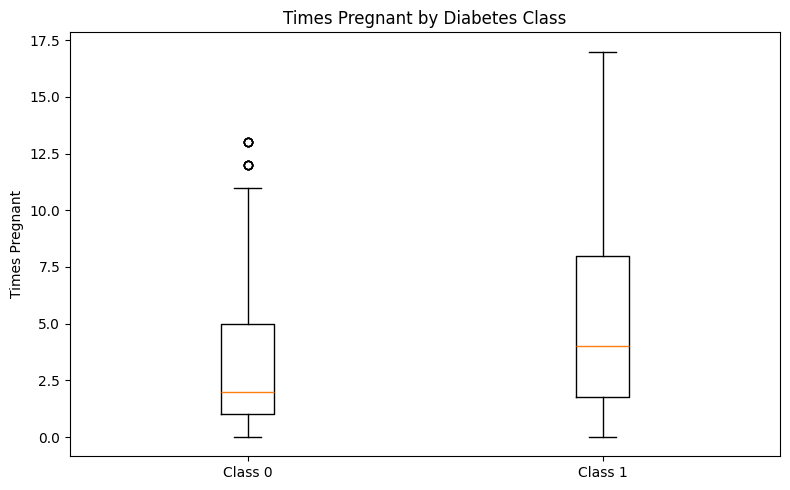

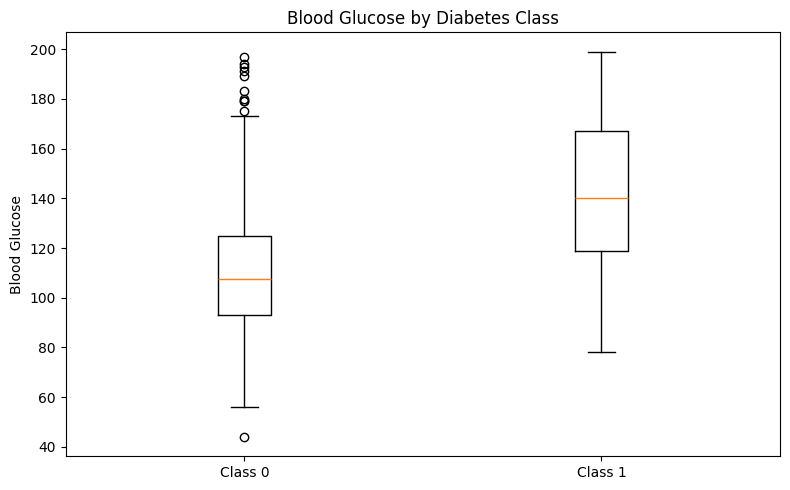

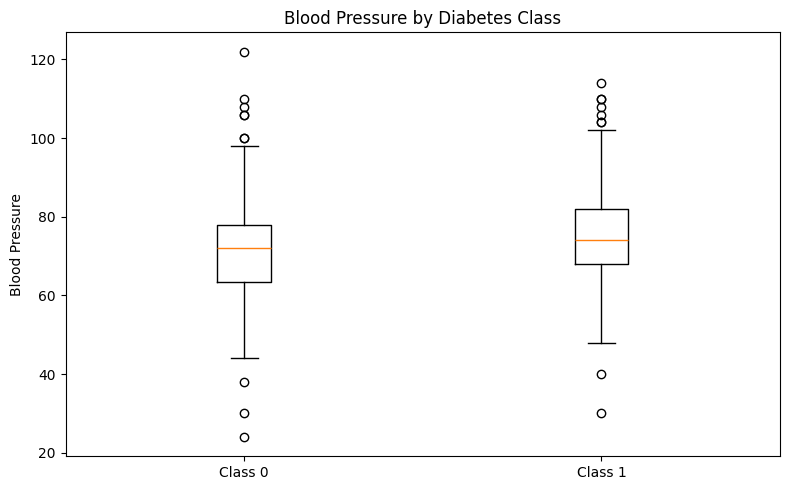

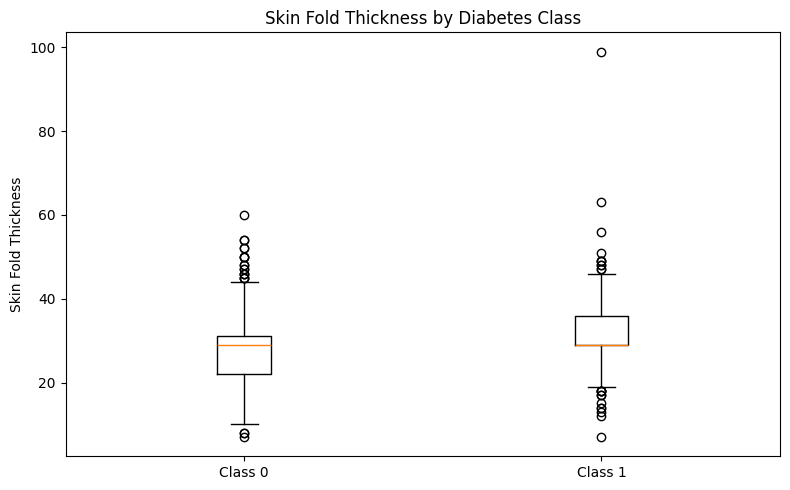

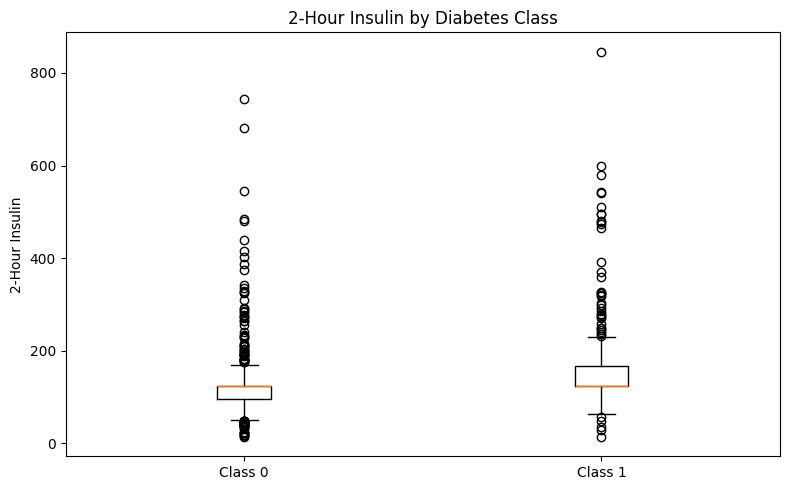

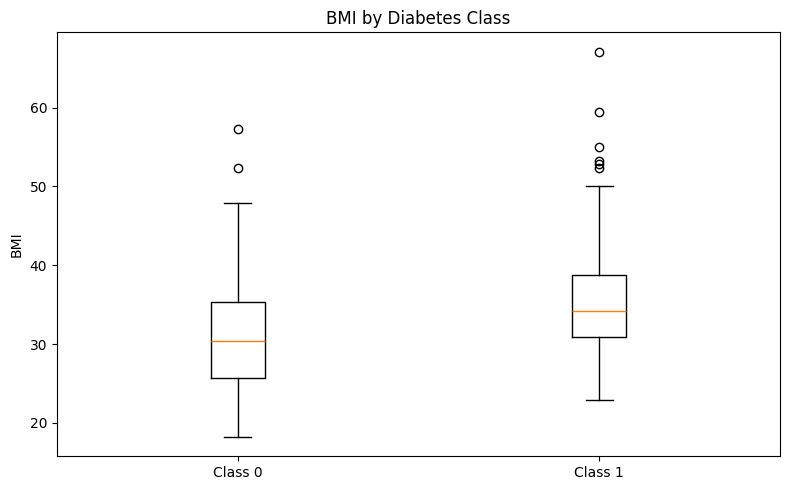

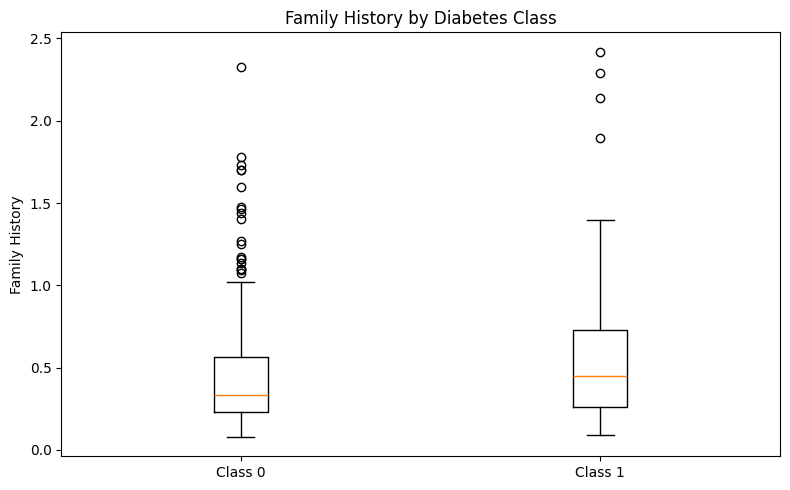

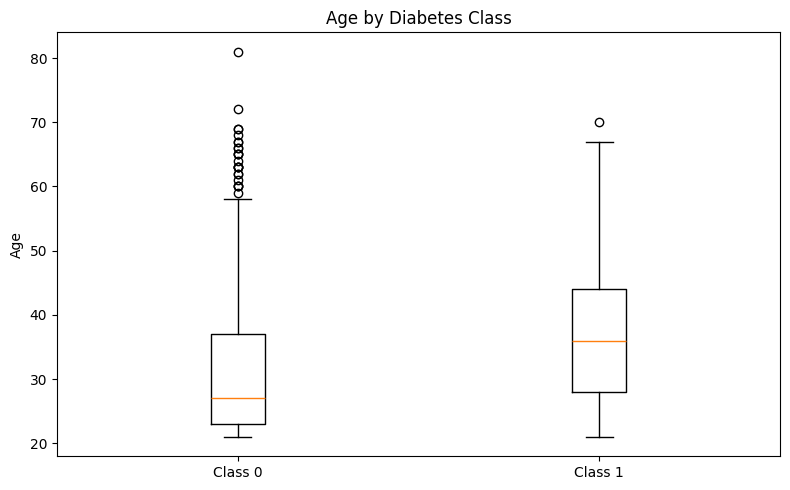

In [26]:
for feature in feature_columns:
    plt.figure(figsize=(8, 5))

    data_0 = clean_df[clean_df["Class"] == 0][feature]
    data_1 = clean_df[clean_df["Class"] == 1][feature]

    plt.boxplot([data_0, data_1], tick_labels=["Class 0", "Class 1"])
    plt.title(f"{feature} by Diabetes Class")
    plt.ylabel(feature)
    plt.tight_layout()

    safe_name = feature.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(fig_path / f"boxplot_{safe_name}_by_class.png", dpi=300, bbox_inches="tight")
    plt.show()

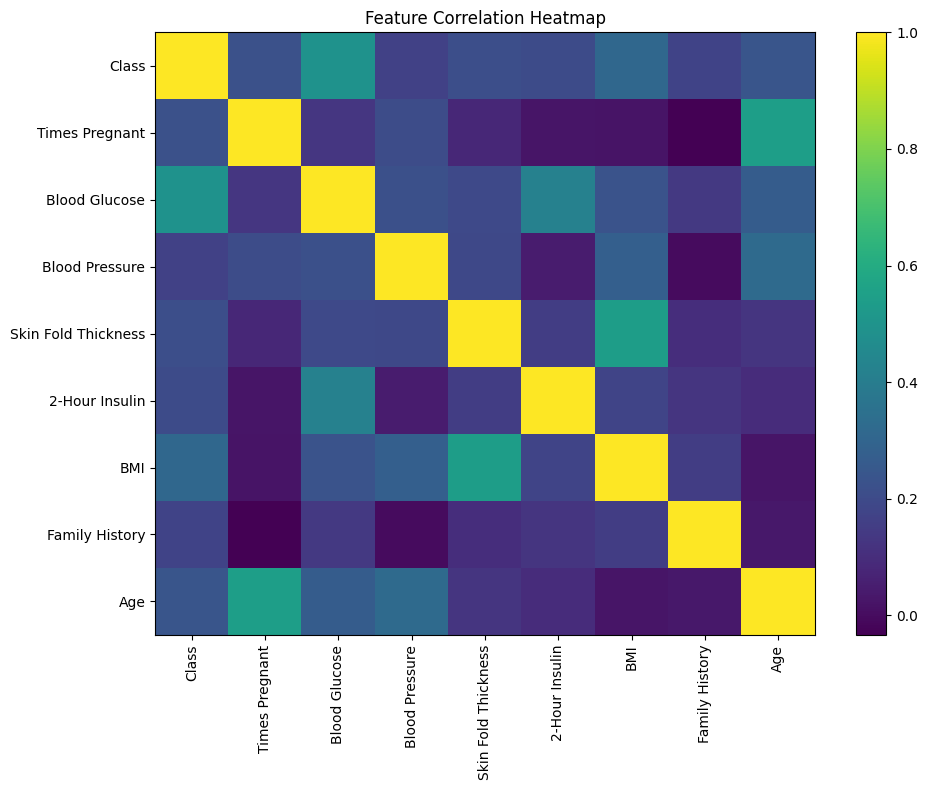

In [27]:
corr = clean_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(fig_path / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
summary_table = clean_df.describe().T
summary_table["missing_after_cleaning"] = clean_df.isna().sum()
summary_table["class_0_mean"] = [
    clean_df[clean_df["Class"] == 0][col].mean() if col != "Class" else clean_df[clean_df["Class"] == 0][col].mean()
    for col in summary_table.index
]
summary_table["class_1_mean"] = [
    clean_df[clean_df["Class"] == 1][col].mean() if col != "Class" else clean_df[clean_df["Class"] == 1][col].mean()
    for col in summary_table.index
]

table_path = project_root / "outputs" / "tables"
table_path.mkdir(parents=True, exist_ok=True)
summary_table.to_csv(table_path / "eda_summary_table.csv")

summary_table

,count,mean,std,min,25%,50%,75%,max,missing_after_cleaning,class_0_mean,class_1_mean
Class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00,0,0.000000,1.000000
Times Pregnant,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00,0,3.298000,4.865672
Blood Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00,0,110.682000,142.130597
Blood Pressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00,0,70.920000,75.123134
Skin Fold Thickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00,0,27.726000,31.686567
2-Hour Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00,0,127.792000,164.701493
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10,0,30.885600,35.383582
Family History,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42,0,0.429734,0.550500
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00,0,31.190000,37.067164


In [29]:
import json
from pathlib import Path

metrics_path = project_root / "outputs" / "metrics" / "random_forest_metrics.json"

with open(metrics_path, "r") as f:
    rf_metrics = json.load(f)

rf_metrics

{'accuracy': 0.7727272727272727,
 'precision': 0.7111111111111111,
 'recall': 0.5925925925925926,
 'f1': 0.6464646464646465,
 'roc_auc': 0.8114814814814815}

## Random Forest Baseline
This baseline provides a strong classical machine learning benchmark for static diabetes prediction on the Pima dataset. Because tree-based models performed well in earlier coursework, Random Forest serves as an important comparison point for testing whether a more complex neural approach is actually necessary.

In [30]:
import json

gb_metrics_path = project_root / "outputs" / "metrics" / "gradient_boosting_metrics.json"

with open(gb_metrics_path, "r") as f:
    gb_metrics = json.load(f)

gb_metrics

{'accuracy': 0.7467532467532467,
 'precision': 0.6470588235294118,
 'recall': 0.6111111111111112,
 'f1': 0.6285714285714286,
 'roc_auc': 0.8214814814814815}

## Gradient Boosting Baseline
Gradient Boosting serves as a second strong classical benchmark and helps test the professor’s feedback directly. By comparing it with Random Forest and the later LSTM model, the project can evaluate whether additional model complexity actually improves performance on this static tabular dataset.

In [31]:
import json

lstm_metrics_path = project_root / "outputs" / "metrics" / "lstm_metrics.json"

with open(lstm_metrics_path, "r") as f:
    lstm_metrics = json.load(f)

lstm_metrics

{'accuracy': 0.7077922077922078,
 'precision': 0.5918367346938775,
 'recall': 0.5370370370370371,
 'f1': 0.5631067961165048,
 'roc_auc': 0.7696296296296297}

## LSTM Model on Static Tabular Input
Because the Pima dataset does not contain repeated patient visits, the LSTM in this project does not model true longitudinal disease progression. Instead, the standardized feature vector for each patient is reshaped into a short ordered sequence so that an LSTM style architecture can be tested against strong classical machine learning baselines. This makes the comparison honest while still evaluating whether a recurrent deep learning model offers any benefit on this dataset.

### Interpretation Note
This experiment should not be interpreted as evidence that LSTMs are appropriate for static tabular clinical data in general. Rather, it is a controlled comparison showing whether a more complex recurrent architecture provides measurable gains over well established tree based baselines on the Pima diabetes dataset.

In [32]:
import pandas as pd

final_results_path = project_root / "outputs" / "tables" / "final_model_comparison_rounded.csv"
rank_summary_path = project_root / "outputs" / "tables" / "model_rank_summary.csv"

final_results_df = pd.read_csv(final_results_path)
rank_summary_df = pd.read_csv(rank_summary_path)

display(final_results_df)
display(rank_summary_df[["model", "average_rank"]])

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.7727,0.7111,0.5926,0.6465,0.8115
1,Gradient Boosting,0.7468,0.6471,0.6111,0.6286,0.8215
2,LSTM,0.7078,0.5918,0.5370,0.5631,0.7696


,model,average_rank
0,Random Forest,1.4
1,Gradient Boosting,1.6
2,LSTM,3.0


## Final Comparison Summary
Across all three models, the classical machine learning baselines outperformed the adapted LSTM on the static Pima diabetes dataset. Random Forest achieved the strongest accuracy and F1 score, while Gradient Boosting achieved the strongest ROC AUC. These results support the conclusion that increased neural network complexity did not provide a performance advantage on this dataset.

### Key Takeaway
This project demonstrates the importance of evaluating model complexity empirically rather than assuming that a deep learning model will outperform classical methods. On small structured clinical tabular data such as Pima, tree based ensembles remained the strongest overall approach.